In [1]:
import torch
from calibr_polar import *
import copy

import matplotlib.pyplot as plt

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print("Using GPU")
else:   
    device = torch.device('cpu')
    print("Using CPU")

Using CPU


In [51]:
res1, res2, res3, res4, res5, res6 = extract_calibr('Z:\\DATA\\4polar_data_raw\\2026_01_16_calibr_polar_objectif\\Calib_Polar_2026-01-16_0\\images\\RAW_DATA\\image_Pos0.ome.tif')

<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_meta

In [52]:
zer = zero('Z:\\DATA\\4polar_data_raw\\2026_01_16_calibr_polar_objectif\\Calib_Polar_2026-01-16_0\\images\\RAW_DATA\\image_Pos0.ome.tif')

<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')


In [53]:
intensity = open_ome('Z:\\DATA\\4polar_data_raw\\PolMFM_SilicaBeads_SLB_NR\\Calibration\\Calib-Intensity_NoPolar_TL3D_filter617nm\\Calib_Polar_2024-01-11\\images\\RAW_DATA\\image_Pos0.ome.tif')

<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')


In [54]:
i1, i2, i3, i4, i5, i6 = extract_sqr(intensity)

In [55]:
i1-=zer
i2-=zer
i3-=zer
i4-=zer
i5-=zer
i6-=zer

In [56]:
res1-=zer
res2-=zer
res3-=zer
res4-=zer
res5-=zer
res6-=zer

In [57]:
res1/=i1
res2/=i2
res3/=i3
res4/=i4
res5/=i5
res6/=i6

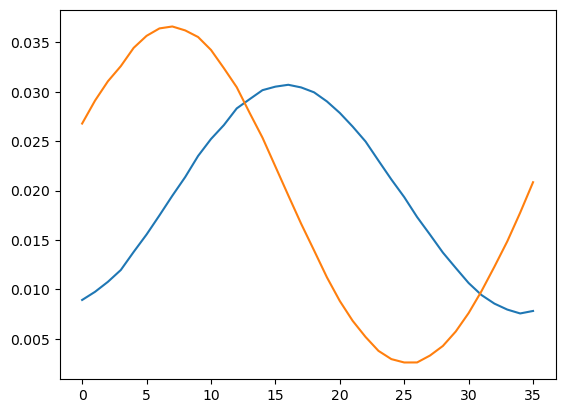

In [58]:
plt.plot(res1)
#plt.plot(res2)
plt.plot(res3)
#plt.plot(res4)
#plt.plot(res5)
#plt.plot(res6)

In [59]:
a1 = 1.
b1 = 0.001
b2 = 0.001
c1 = 0.001
c2 = 0.001
d1 = -1.
d2 = 0.001

I0 = 1.
offset=0*np.pi/180.
alpha = 22.25
alpha_start = copy.deepcopy(alpha)

In [77]:
def through_microscope(I0, a1, b1, b2, c1, c2, d1, d2, alpha, offset):
    J = torch.stack([
        torch.stack([a1, b1 + 1j*b2]),
        torch.stack([c1 + 1j*c2, d1 + 1j*d2])
    ]
    ).to(torch.complex128)
    phii = (torch.linspace(np.pi/2, 1.5*np.pi, 37)+offset)[:-1]
    input_ = I0*torch.stack([torch.cos(phii), torch.sin(phii)]).to(device).to(torch.complex128)
    output_ = torch.einsum('ab,bc->ac', J, input_)
    #aa1, bb1, bb2, cc1, cc2, dd1, dd2 = 1.0065e+00,  1.1120e-02,  2.1056e-02, -4.6805e-02, -1.7288e-01,  9.9881e-01,  1.5819e-01
    #Jw = J = torch.tensor([
     #   [aa1, bb1 + 1j*bb2],
     #   [cc1 + 1j*cc2, dd1 + 1j*dd2]
   #]
   # ).to(torch.complex128)
    output_2 =  rotation(alpha, output_) #torch.einsum('ab,bc->ac', Jw, rotation(alpha, output_))
    return (output_[0]*torch.conj(output_[0])).to(torch.float64), (output_[1]*torch.conj(output_[1])).to(torch.float64), (output_2[0]*torch.conj(output_2[0])).to(torch.float64), (output_2[1]*torch.conj(output_2[1])).to(torch.float64)

In [78]:
def rotation(alpha, inp): # input is a vector Ex, Ey
    alpha = alpha*torch.pi/180
    Rot = torch.stack([
        torch.stack([torch.cos(alpha), -torch.sin(alpha)]),
        torch.stack([torch.sin(alpha),torch.cos(alpha)])
    ]).to(torch.complex128)
    lambda_2 = torch.tensor([
    [1., 0.],
    [0., -1.]
    ]).to(torch.complex128)
    final = torch.einsum('ab,bc->ac', Rot, torch.einsum('ab,bc->ac', lambda_2, torch.inverse(Rot)))
    return torch.einsum('ab,bc->ac', final, inp)

In [79]:
res1 = torch.tensor(res1, device=device)
res2 = torch.tensor(res2, device=device)
res3 = torch.tensor(res3, device=device)
res4 = torch.tensor(res4, device=device)
res5 = torch.tensor(res5, device=device)
res6 = torch.tensor(res6, device=device)

C:\Users\LOCCO_Louise\AppData\Local\Temp\ipykernel_22984\1781850405.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  res1 = torch.tensor(res1, device=device)
C:\Users\LOCCO_Louise\AppData\Local\Temp\ipykernel_22984\1781850405.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  res2 = torch.tensor(res2, device=device)
C:\Users\LOCCO_Louise\AppData\Local\Temp\ipykernel_22984\1781850405.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  res3 = torch.tensor(res3, device=device)
C:\Users\LOCCO_Louise\AppData\Local\Temp\ipykernel_22984\1781

In [80]:
params = torch.tensor([I0, a1, b1, b2, c1, c2, d1, d2, alpha, offset], device=device)
params.requires_grad=True
optimizer = torch.optim.Adam([params], lr=.05)
loss_ = []

In [95]:
def loss_f(para):
    I0, a1, b1, b2, c1, c2, d1, d2, alpha, offset = para[0], para[1], para[2], para[3], para[4], para[5], para[6], para[7] , para[8], para[9]
    th1, th2, th3, th4 = through_microscope(I0, a1, b1, b2, c1, c2, d1, d2, alpha, offset) 
    J = torch.stack([
        torch.stack([a1, b1 + 1j*b2]),
        torch.stack([c1 + 1j*c2, d1 + 1j*d2])
    ]
    ).to(torch.complex128)
    force_angle = ((alpha-alpha_start)**2)/1000
    force_offset = (offset**2)/100
    force_unitary = 0.00001*torch.sum(torch.abs((torch.einsum('ab, bc-> ac', torch.transpose(torch.conj(J), 0, 1), J)-torch.ones(2))**2))
    #force_unitary = (a1**2+b1**2+b2**2+c1**2+c2**2+d1**2+d2**2-1)**2
    return torch.sum((th1-res1)**2)+torch.sum((th2-res2)**2) + torch.sum((th3-res3)**2)+torch.sum((th4-res4)**2) + force_offset + (I0-torch.abs(I0))**2 + (a1-torch.abs(a1))**2 + force_angle + force_unitary

In [96]:
for i in range(1000):
    optimizer.zero_grad()
    loss=loss_f(params)
    loss.backward()  # Backpropagation
    optimizer.step()
    loss_.append(loss.detach().numpy())

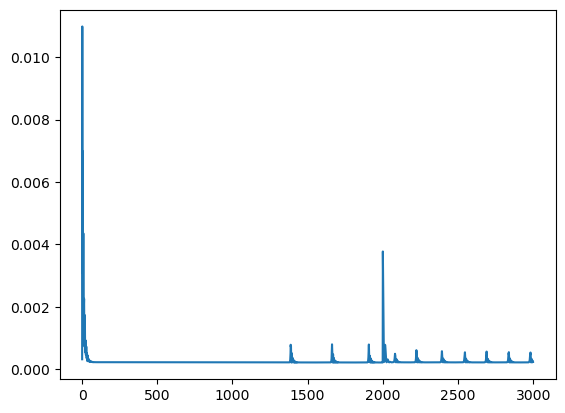

In [97]:
plt.plot(loss_)

In [98]:
print('I0 = ', params[0].detach().numpy())
print('J = ', params[1].detach().numpy(), '                   ', params[2].detach().numpy(), '+ i ', params[3].detach().numpy())
print('     ', params[4].detach().numpy(), '+ i ', params[5].detach().numpy(), '   ', params[6].detach().numpy(), '+ i ', params[7].detach().numpy())
print('angle : ', params[8].detach().numpy())
print('offset : ', params[9].detach().numpy()*180/np.pi)

I0 =  0.27828547
J =  0.6152142                     -0.07071821 + i  -0.32384807
      -0.11067753 + i  0.28322944     -0.6181744 + i  -0.08643947
angle :  22.249905
offset :  -0.14461175


In [102]:
I0, a1, b1, b2, c1, c2, d1, d2, alpha, offset = params[0], params[1], params[2], params[3], params[4], params[5], params[6], params[7] , params[8], params[9]
J = torch.stack([
        torch.stack([a1, b1 + 1j*b2]),
        torch.stack([c1 + 1j*c2, d1 + 1j*d2])
    ]
    ).to(torch.complex128)
force_unitary = torch.sum(torch.abs((torch.einsum('ab, bc-> ac', torch.transpose(torch.conj(J), 0, 1), J)-torch.ones(2))**2))
print(force_unitary)

tensor(2.5291, dtype=torch.float64, grad_fn=<SumBackward0>)


In [103]:
predicted1, predicted2, predicted3, predicted4 = through_microscope(params[0], params[1], params[2], params[3], params[4], params[5], params[6], params[7], params[8], params[9])
predicted1 = predicted1.detach().numpy()
predicted2 = predicted2.detach().numpy()
predicted3 = predicted3.detach().numpy()
predicted4 = predicted4.detach().numpy()

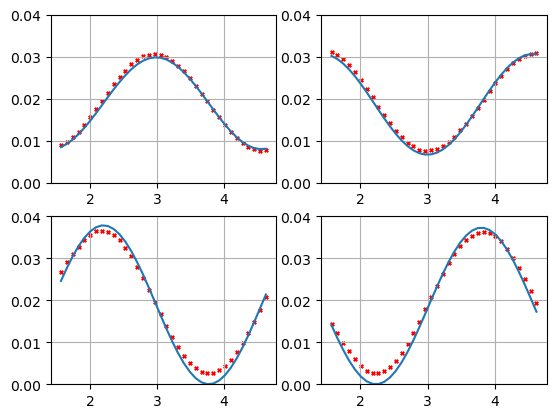

In [104]:
fig, ax = plt.subplots(2,2)
phi = (np.linspace(np.pi/2, 1.5*np.pi, 37)+params[9].detach().numpy())[:-1]
ax[0,0].plot(phi, predicted1)
ax[0,0].scatter(phi, res1, c='r', marker='x', s=6)
ax[0,0].set_ylim((0., 0.04))
ax[0,0].grid()
ax[0,1].plot(phi, predicted2)
ax[0,1].scatter(phi, res2, c='r', marker='x', s=6)
ax[0,1].set_ylim((0., 0.04))
ax[0,1].grid()
ax[1,0].plot(phi, predicted3)
ax[1,0].scatter(phi, res3, c='r', marker='x', s=6)
ax[1,0].set_ylim((0., 0.04))
ax[1,0].grid()
ax[1,1].plot(phi, predicted4)
ax[1,1].scatter(phi, res4, c='r', marker='x', s=6)
ax[1,1].set_ylim((0., 0.04))
ax[1,1].grid()

# Calibration before grating

In [38]:
res1, res2, res3, res4, res5, res6 = extract_calibr('Z:\\DATA\\4polar_data_raw\\2026_01_16_calibr_polar_inside\\Calib_Polar_2026-01-16_0\\images\\RAW_DATA\\image_Pos0.ome.tif')

<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_meta

In [39]:
#zer = zero('Z:\\DATA\\4polar_data\\2025-12-16 - calibration_polarizeur_after_grating_graduations_microscope_side\\Calib_Polar_2025-12-16_0\\images\\RAW_DATA\\image_Pos0.ome.tif')
zer = np.min(np.array([np.min(res1), np.min(res2), np.min(res3), np.min(res4), np.min(res5), np.min(res6)]))
res1-=zer
res2-=zer
res3-=zer
res4-=zer
res5-=zer
res6-=zer

In [40]:
res1/=i1
res2/=i2
res3/=i3
res4/=i4
res5/=i5
res6/=i6

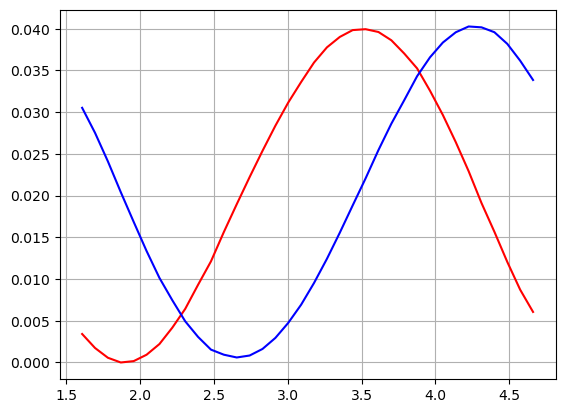

In [41]:
plt.plot(phi, res1, c='r')
#plt.plot(phi, res2, c='g')
plt.plot(phi, res3, c='b')
#plt.plot(phi, res4, c='y')
#plt.plot(phi, res5)
#plt.plot(phi, res6)
plt.grid()

In [42]:
res1 = torch.tensor(res1.copy(), device=device)
res2 = torch.tensor(res2.copy(), device=device)
res3 = torch.tensor(res3.copy(), device=device)
res4 = torch.tensor(res4.copy(), device=device)
res5 = torch.tensor(res5.copy(), device=device)
res6 = torch.tensor(res6.copy(), device=device)

In [43]:
def through_end_microscope(I0, angle, e1, f1, f2, g1, g2, h1, h2, offset):
    phii = (torch.linspace(np.pi/2, 1.5*np.pi, 37)+offset)[:-1]
    input_ = I0*torch.stack([torch.cos(phii), torch.sin(phii)]).to(device).to(torch.complex128)
    output_ = input_
    J2 = torch.stack([
        torch.stack([e1, f1 + 1j*f2]),
        torch.stack([g1 + 1j*g2, h1 + 1j*h2])
    ]
    ).to(torch.complex128)
    output_2 =  torch.einsum('ab,bc->ac', J2, rotation(angle, output_))
    return (output_[0]*torch.conj(output_[0])).to(torch.float64), (output_[1]*torch.conj(output_[1])).to(torch.float64), (output_2[0]*torch.conj(output_2[0])).to(torch.float64), (output_2[1]*torch.conj(output_2[1])).to(torch.float64)

In [44]:
def loss_f2(para):
    I0, angle, e1, f1, f2, g1, g2, h1, h2, offset = para[0], para[1], para[2], para[3], para[4], para[5], para[6], para[7], para[8], para[9]
    th1, th2, th3, th4 = through_end_microscope(I0, angle, e1, f1, f2, g1, g2, h1, h2, offset) 
    return torch.sum((th1-res1)**2)+torch.sum((th2-res2)**2) + (I0-torch.abs(I0))**2 + torch.sum((th3-res3)**2)+torch.sum((th4-res4)**2) + (offset**2)/200 + (e1-torch.abs(e1))**2 + (h1-torch.abs(h1))**2 + 0.01*(angle-22.5)**2

In [45]:
params = torch.tensor([0.3, 22.5, 1., 0.001, 0.001, 0.001, 0.001, 1., 0.001, 0.0001], device=device)
params.requires_grad=True
optimizer = torch.optim.Adam([params], lr=1.)
loss_ = []

In [46]:
for i in range(4000):
    optimizer.zero_grad()
    loss=loss_f2(params)
    loss.backward()  # Backpropagation
    optimizer.step()
    loss_.append(loss.detach().numpy())

In [47]:
predicted1, predicted2, predicted3, predicted4 = through_end_microscope(params[0], params[1], params[2], params[3], params[4], params[5], params[6], params[7], params[8], params[9])
predicted1 = predicted1.detach().numpy()
predicted2 = predicted2.detach().numpy()
predicted3 = predicted3.detach().numpy()
predicted4 = predicted4.detach().numpy()

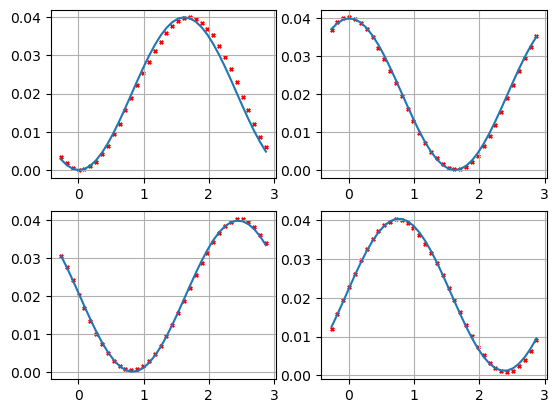

In [48]:
fig, ax = plt.subplots(2,2)
#phi1 = np.linspace(0+params[2].detach().numpy()*np.pi/180, np.pi+params[2].detach().numpy()*np.pi/180, 36)
phi2 = np.linspace(0, np.pi, 36)+params[9].detach().numpy()
phi1=phi2
ax[0,0].plot(phi1, predicted1)
ax[0,0].scatter(phi2, res1, c='r', marker='x', s=6)
ax[0,0].grid()
ax[0,1].plot(phi1, predicted2)
ax[0,1].scatter(phi2, res2, c='r', marker='x', s=6)
ax[0,1].grid()
ax[1,0].plot(phi1, predicted3)
ax[1,0].scatter(phi2, res3, c='r', marker='x', s=6)
ax[1,0].grid()
ax[1,1].plot(phi1, predicted4)
ax[1,1].scatter(phi2, res4, c='r', marker='x', s=6)
ax[1,1].grid()

In [49]:
params

tensor([ 1.9996e-01,  2.2500e+01,  9.9797e-01, -1.5055e-02, -5.9084e-02,
        -1.7521e-01,  1.3149e-03,  2.6759e-01, -9.6816e-01, -2.6742e-01],
       requires_grad=True)